In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
import sys
import os

os.environ['MUJOCO_GL'] = 'egl'

sys.path.append('../diffusion_policy')  # path to cloned repo

from diffusion_policy.model.diffusion.conditional_unet1d import ConditionalUnet1D
from diffusion_policy.model.common.normalizer import LinearNormalizer
from diffusion_policy.policy.diffusion_unet_lowdim_policy import DiffusionUnetLowdimPolicy

In [2]:
class LocomotionDataset(Dataset):
    def __init__(self, demos, n_obs_steps=2, horizon=8):
        self.obs_dim = 103
        self.action_dim = 29
        self.n_obs_steps = n_obs_steps
        self.horizon = horizon

        # flatten all episodes into overlapping windows
        self.obs_windows = []
        self.action_windows = []

        for ep in demos:
            obs = ep['obs']       # (T, 103)
            action = ep['action'] # (T, 29)
            T = len(obs)

            for t in range(T - horizon + 1):
                # obs window: n_obs_steps ending at t
                obs_start = max(0, t - n_obs_steps + 1)
                obs_window = obs[obs_start:t+1]
                # pad if at start of episode
                if len(obs_window) < n_obs_steps:
                    pad = np.repeat(obs_window[:1], n_obs_steps - len(obs_window), axis=0)
                    obs_window = np.concatenate([pad, obs_window], axis=0)

                self.obs_windows.append(obs_window)             # (n_obs_steps, 103)
                self.action_windows.append(action[t:t+horizon]) # (horizon, 29)

        self.obs_windows = np.array(self.obs_windows, dtype=np.float32)
        self.action_windows = np.array(self.action_windows, dtype=np.float32)
        print(f"Dataset: {len(self.obs_windows)} windows")
        print(f"obs_windows shape: {self.obs_windows.shape}")
        print(f"action_windows shape: {self.action_windows.shape}")

    def __len__(self):
        return len(self.obs_windows)

    def __getitem__(self, idx):
        return {
            'obs': torch.from_numpy(self.obs_windows[idx]),       # (n_obs_steps, 103)
            'action': torch.from_numpy(self.action_windows[idx])  # (horizon, 29)
        }

In [3]:
def fit_normalizer(demos, device):
    all_obs = np.concatenate([ep['obs'] for ep in demos], axis=0)
    all_actions = np.concatenate([ep['action'] for ep in demos], axis=0)

    normalizer = LinearNormalizer()
    normalizer.fit({
        'obs': torch.from_numpy(all_obs).float(),
        'action': torch.from_numpy(all_actions).float()
    })
    normalizer.to(device)
    return normalizer

In [4]:
def make_policy(obs_dim=103, action_dim=29, n_obs_steps=2, horizon=8, n_action_steps=4, device='cuda'):
    model = ConditionalUnet1D(
        input_dim=action_dim,
        global_cond_dim=obs_dim * n_obs_steps,  # flattened obs
        diffusion_step_embed_dim=128,
        down_dims=[256, 512, 1024],
        kernel_size=5,
        n_groups=8,
    )

    noise_scheduler = DDPMScheduler(
        num_train_timesteps=100,
        beta_schedule='squaredcos_cap_v2',
        clip_sample=True,
        prediction_type='epsilon'
    )

    policy = DiffusionUnetLowdimPolicy(
        model=model,
        noise_scheduler=noise_scheduler,
        horizon=horizon,
        obs_dim=obs_dim,
        action_dim=action_dim,
        n_action_steps=n_action_steps,
        n_obs_steps=n_obs_steps,
        obs_as_global_cond=True,
        num_inference_steps=100,
    )
    policy.to(device)
    return policy

In [5]:
def train(demos, n_epochs=100, batch_size=256, lr=1e-4, device='cuda'):
    n_obs_steps = 2
    horizon = 8
    n_action_steps = 4

    dataset = LocomotionDataset(
        demos,
        n_obs_steps=n_obs_steps,
        horizon=horizon
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                            num_workers=4, pin_memory=True)

    policy = make_policy(n_obs_steps=n_obs_steps, horizon=horizon,
                         n_action_steps=n_action_steps, device=device)

    normalizer = fit_normalizer(demos, device)
    policy.set_normalizer(normalizer)

    optimizer = torch.optim.AdamW(policy.parameters(), lr=lr, weight_decay=1e-6)


    epoch_losses = []
    
    for epoch in range(n_epochs):
        losses = []
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            loss = policy.compute_loss(batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())
    
        epoch_loss = np.mean(losses)
        epoch_losses.append(epoch_loss)
    
        if epoch % 10 == 0:
            clear_output(wait=True)
            plt.figure(figsize=(10, 4))
            plt.plot(epoch_losses)
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title(f'Epoch {epoch} | Loss {epoch_loss:.4f}')
            plt.yscale('log')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    return policy, normalizer

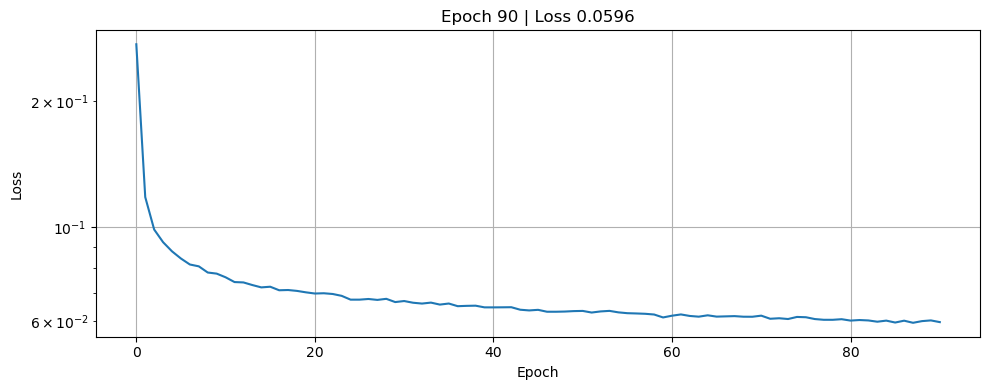

In [6]:
demos = np.load("data/demonstrations/g1_walking/demos.npy", allow_pickle=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
policy, normalizer = train(demos, n_epochs=100, device=device)

# save
torch.save({
    'policy': policy.state_dict(),
    'normalizer': normalizer.state_dict()
}, 'diffusion_policy_locomotion.pt')

In [6]:
device = "cuda"

checkpoint = torch.load('diffusion_policy_locomotion.pt', map_location=device)

policy = make_policy(device=device)
policy.load_state_dict(checkpoint['policy'])

normalizer = LinearNormalizer()
normalizer.load_state_dict(checkpoint['normalizer'])
normalizer.to(device)

policy.set_normalizer(normalizer)
policy.eval()

DiffusionUnetLowdimPolicy(
  (model): ConditionalUnet1D(
    (mid_modules): ModuleList(
      (0-1): 2 x ConditionalResidualBlock1D(
        (blocks): ModuleList(
          (0-1): 2 x Conv1dBlock(
            (block): Sequential(
              (0): Conv1d(1024, 1024, kernel_size=(5,), stride=(1,), padding=(2,))
              (1): GroupNorm(8, 1024, eps=1e-05, affine=True)
              (2): Mish()
            )
          )
        )
        (cond_encoder): Sequential(
          (0): Mish()
          (1): Linear(in_features=334, out_features=1024, bias=True)
          (2): Rearrange('batch t -> batch t 1')
        )
        (residual_conv): Identity()
      )
    )
    (diffusion_step_encoder): Sequential(
      (0): SinusoidalPosEmb()
      (1): Linear(in_features=128, out_features=512, bias=True)
      (2): Mish()
      (3): Linear(in_features=512, out_features=128, bias=True)
    )
    (up_modules): ModuleList(
      (0): ModuleList(
        (0): ConditionalResidualBlock1D(
         

In [7]:
def run_diffusion_policy(policy, normalizer, eval_env, env_cfg, device='cuda'):
    policy.eval()

    eval_env = registry.load(env_name)
    env_cfg = registry.get_default_config(env_name)
    env_cfg.push_config.enable = False  # Disable random pushes
    
    jit_reset = jax.jit(eval_env.reset)
    jit_step = jax.jit(eval_env.step)

    rng = jax.random.PRNGKey(42)

    # observation buffer — handles the padding for first n_obs_steps
    n_obs_steps = 2
    obs_buffer = []

    rollout = []
    rollout_actions = []
    action_queue = []  # receding horizon: execute Ta actions before replanning
    
    x_vel = 1.0
    y_vel = 0.0
    yaw_vel = 0.0
    command = jp.array([x_vel, y_vel, yaw_vel])

    phase_dt = 2 * jp.pi * eval_env.dt * 1.5
    phase = jp.array([0, jp.pi])


    state = jit_reset(rng)
    state.info["phase_dt"] = phase_dt
    state.info["phase"] = phase
    state.info["command"] = command

    for i in range(env_cfg.episode_length):

        # 1. update obs buffer
        obs = np.array(state.obs['state'])  # (103,)
        obs_buffer.append(obs)
        if len(obs_buffer) > n_obs_steps:
            obs_buffer.pop(0)

        # pad if not enough obs yet
        while len(obs_buffer) < n_obs_steps:
            obs_buffer.insert(0, obs_buffer[0])

        # 2. replan when action queue is empty
        if len(action_queue) == 0:
            obs_input = np.array(obs_buffer)  # (n_obs_steps, 103)
            obs_tensor = torch.from_numpy(obs_input).float().unsqueeze(0).to(device)  # (1, 2, 103)

            with torch.no_grad():
                result = policy.predict_action({'obs': obs_tensor})

            actions = result['action'][0].cpu().numpy()  # (n_action_steps, 29)
            action_queue = list(actions)

        # 3. execute next action
        ctrl = action_queue.pop(0)
        ctrl_jax = jp.array(ctrl)

        state = jit_step(state, ctrl_jax)
        state.info["command"] = command
        rollout.append(state)
        rollout_actions.append(ctrl_jax)

        if state.done:
            break

    return rollout, rollout_actions

In [8]:
from mujoco_playground import registry
import jax
from jax import numpy as jp

env_name = "G1JoystickFlatTerrain"
env_cfg = registry.get_default_config(env_name)
eval_env = registry.load(env_name)

In [9]:
rollout, rollout_actions = run_diffusion_policy(policy, normalizer, eval_env, env_cfg)

/mnt/iusers01/fse-ugpgt01/compsci01/c41098yp/.conda/envs/diffmimic-3/lib/python3.11/site-packages/jax/_src/abstract_arrays.py:140: RuntimeWarning: overflow encountered in cast
  return literals.TypedNdArray(np.asarray(x, dtype), weak_type=False)


In [10]:
len(rollout)

159

In [ ]:
# Import packages for plotting and creating graphics
import os
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
import mediapy as media

import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

import mujoco
import mujoco_playground

In [12]:
render_every = 1
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")
traj = rollout[::render_every]
# mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640*2,
    height=480,
    # modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)

fps: 50.0


100%|██████████| 159/159 [00:00<00:00, 361.49it/s]


This browser does not support the video tag.


In [25]:
policy_actions = [state.data.qpos[7:] for state in rollout]
policy_actions[0].shape

(29,)

In [ ]:
demos = np.load("data/demonstrations/g1_walking/demos.npy", allow_pickle=True)


demo_actions = np.concatenate([ep['action'] for ep in demos])
print("demo action mean:", demo_actions.mean(axis=0))
print("demo action std:", demo_actions.std(axis=0))

print("policy action mean:", np.mean(policy_actions, axis=0))
print("policy action std:", np.std(policy_actions, axis=0))

demo action mean: [ 0.119  0.212 -0.153 -0.066  0.126 -0.028  0.054 -0.209  0.163 -0.095 -0.012  0.023 -0.067  0.037
 -0.199 -0.07   0.078 -0.    -0.066  0.078 -0.141  0.031 -0.068 -0.021  0.053 -0.091  0.102  0.031
  0.025]
demo action std: [0.386 0.359 0.285 0.681 0.447 0.102 0.422 0.363 0.278 0.668 0.435 0.103 0.136 0.191 0.182 0.203
 0.268 0.139 0.108 0.09  0.095 0.137 0.142 0.24  0.093 0.118 0.157 0.139 0.123]
policy action mean: [-0.286 -0.021 -0.     0.81  -0.4    0.042 -0.278  0.001  0.008  0.812 -0.43  -0.015 -0.029  0.002
 -0.007  0.162  0.215  0.009  0.596  0.034  0.053 -0.01   0.156 -0.223  0.004  0.586  0.031  0.118
  0.006]
policy action std: [0.216 0.059 0.069 0.221 0.152 0.068 0.222 0.071 0.071 0.224 0.164 0.058 0.115 0.105 0.107 0.12
 0.113 0.063 0.054 0.022 0.098 0.04  0.057 0.102 0.05  0.048 0.028 0.097 0.037]
